
STEP 1: MCP Neuron — AND Function


In [1]:
def MCP_Neurons_AND(X1, X2, T):
    """
    MCP neuron for AND operation
    """
    assert len(X1) == len(X2)

    state_neuron = []

    for i in range(len(X1)):
        s = X1[i] + X2[i]

        if s >= T:
            state_neuron.append(1)
        else:
            state_neuron.append(0)

    return state_neuron

Test

In [2]:
X1 = [0, 0, 1, 1]
X2 = [0, 1, 0, 1]
T = 2

result = MCP_Neurons_AND(X1, X2, T)
print(result)

[0, 0, 0, 1]


STEP 2: MCP Neuron — OR Function


In [3]:
def MCP_Neurons_OR(X1, X2, T):
    """
    MCP neuron for OR operation
    """
    assert len(X1) == len(X2)

    state_neuron = []

    for i in range(len(X1)):
        s = X1[i] + X2[i]

        if s >= T:
            state_neuron.append(1)
        else:
            state_neuron.append(0)

    return state_neuron

Test

In [4]:
T = 1

result_or = MCP_Neurons_OR(X1, X2, T)
print(result_or)

[0, 1, 1, 1]


 STEP 3: THEORY ANSWERS (Task 1)

Q1: Limitations of MCP Neuron

In [5]:
q1 = """
MCP neurons have several limitations:
1. They can only solve linearly separable problems.
2. They do not support learning; weights are fixed manually.
3. They cannot handle complex patterns like XOR.
4. They use binary inputs and outputs only.
5. No adaptability or optimization mechanism.
"""
print(q1)


MCP neurons have several limitations:
1. They can only solve linearly separable problems.
2. They do not support learning; weights are fixed manually.
3. They cannot handle complex patterns like XOR.
4. They use binary inputs and outputs only.
5. No adaptability or optimization mechanism.



Q2: XOR using MCP?

In [6]:
q2 = """
No, XOR cannot be solved using a single MCP neuron because it is not linearly separable.
There is no single threshold that can separate XOR outputs correctly.

However, we can approximate XOR using multiple MCP neurons with layered logic:
XOR = (A OR B) AND (NOT (A AND B))

But a single MCP neuron cannot implement XOR directly.
"""
print(q2)


No, XOR cannot be solved using a single MCP neuron because it is not linearly separable.
There is no single threshold that can separate XOR outputs correctly.

However, we can approximate XOR using multiple MCP neurons with layered logic:
XOR = (A OR B) AND (NOT (A AND B))

But a single MCP neuron cannot implement XOR directly.



STEP 4: Load Dataset (0 vs 1)

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df_0_1 = pd.read_csv("mnist_0_and_1.csv")

X = df_0_1.drop(columns=["label"]).values
y = df_0_1["label"].values

print("Feature matrix shape:", X.shape)
print("Label vector shape:", y.shape)

Feature matrix shape: (12665, 784)
Label vector shape: (12665,)


STEP 5: THEORY ANSWERS (Shapes)

Q1 & Q2

In [8]:
q_shapes = """
X shape represents number of samples and number of features (pixels).
For MNIST, each image has 784 features (28x28 pixels).

y shape represents number of labels corresponding to each image.
"""
print(q_shapes)


X shape represents number of samples and number of features (pixels).
For MNIST, each image has 784 features (28x28 pixels).

y shape represents number of labels corresponding to each image.



STEP 6: Visualize Images

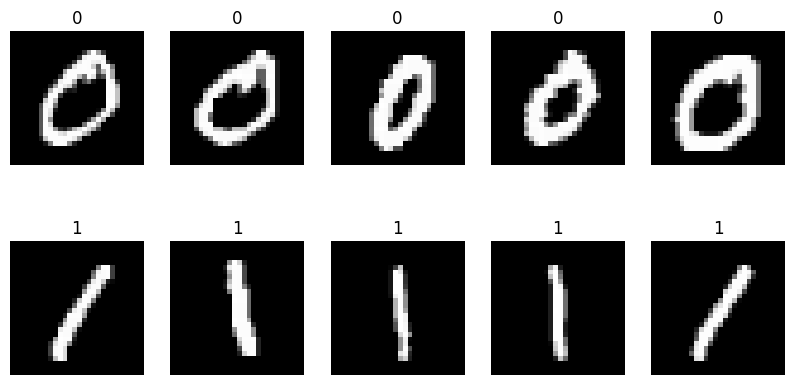

In [9]:
images_0 = X[y == 0]
images_1 = X[y == 1]

fig, axes = plt.subplots(2, 5, figsize=(10, 5))

for i in range(5):
    axes[0, i].imshow(images_0[i].reshape(28, 28), cmap="gray")
    axes[0, i].set_title("0")
    axes[0, i].axis("off")

    axes[1, i].imshow(images_1[i].reshape(28, 28), cmap="gray")
    axes[1, i].set_title("1")
    axes[1, i].axis("off")

plt.show()

STEP 7: Initialize Weights

In [10]:
weights = np.zeros(X.shape[1])
bias = 0
learning_rate = 0.1
epochs = 100

Q3 & Q4

In [11]:
q_weights = """
Weights represent importance of each pixel in classification.

Weights are initialized to zero for simplicity.
During training, they get updated based on errors.

If initialized poorly, learning can be slow or stuck.
"""
print(q_weights)


Weights represent importance of each pixel in classification.

Weights are initialized to zero for simplicity.
During training, they get updated based on errors.

If initialized poorly, learning can be slow or stuck.



STEP 8: Decision Function

In [12]:
def decision_function(X, weights, bias):
    predictions = np.dot(X, weights) + bias

    # Step function
    y_pred_all = np.where(predictions >= 0, 1, 0)

    return y_pred_all

 STEP 9: Train Perceptron

In [14]:
def train_perceptron(X, y, weights, bias, learning_rate=0.1, epochs=100):

    for epoch in range(epochs):
        correct = 0

        for i in range(len(X)):
            output = np.dot(X[i], weights) + bias

            y_pred = 1 if output >= 0 else 0

            if y_pred != y[i]:
                weights = weights + learning_rate * (y[i] - y_pred) * X[i]
                bias = bias + learning_rate * (y[i] - y_pred)
            else:
                correct += 1

        accuracy = correct / len(X)

    return weights, bias, accuracy

STEP 10: THEORY ANSWERS

Q5

In [15]:
q5 = """
This line computes weighted sum of inputs.
It is the core of perceptron where decision boundary is formed.
"""
print(q5)


This line computes weighted sum of inputs.
It is the core of perceptron where decision boundary is formed.



Q6

In [16]:
q6 = """
When prediction is wrong, weights and bias are updated.
Weights = weights + learning_rate * (y - y_pred) * X
Bias = bias + learning_rate * (y - y_pred)

This moves decision boundary towards correct classification.
"""
print(q6)


When prediction is wrong, weights and bias are updated.
Weights = weights + learning_rate * (y - y_pred) * X
Bias = bias + learning_rate * (y - y_pred)

This moves decision boundary towards correct classification.



Q7

In [17]:
q7 = """
Accuracy shows how well the model performs.
For 0 vs 1 classification, we expect high accuracy close to 1.
"""
print(q7)


Accuracy shows how well the model performs.
For 0 vs 1 classification, we expect high accuracy close to 1.



STEP 11: Train Model

In [18]:
weights, bias, accuracy = train_perceptron(X, y, weights, bias)

print("Final Accuracy:", accuracy)

Final Accuracy: 1.0


STEP 12: Misclassified Images

In [19]:
predictions = np.dot(X, weights) + bias
y_pred = np.where(predictions >= 0, 1, 0)

final_accuracy = np.mean(y_pred == y)
print("Final Accuracy:", final_accuracy)

misclassified_idx = np.where(y_pred != y)[0]

if len(misclassified_idx) > 0:
    fig, axes = plt.subplots(2, 5, figsize=(10, 5))

    for ax, idx in zip(axes.flat, misclassified_idx[:10]):
        ax.imshow(X[idx].reshape(28, 28), cmap="gray")
        ax.set_title(f"Pred:{y_pred[idx]} True:{y[idx]}")
        ax.axis("off")

    plt.show()
else:
    print("All images were correctly classified!")

Final Accuracy: 1.0
All images were correctly classified!


 STEP 13: THEORY ANSWERS

Q8

In [20]:
q8 = """
misclassified_idx stores indices of wrongly predicted samples.
It is used to visualize incorrect predictions.
"""
print(q8)


misclassified_idx stores indices of wrongly predicted samples.
It is used to visualize incorrect predictions.



Q9

In [21]:
q9 = """
If all images are correctly classified, it means model achieved perfect accuracy.
However, this is rare and may indicate overfitting or simple dataset.
"""
print(q9)


If all images are correctly classified, it means model achieved perfect accuracy.
However, this is rare and may indicate overfitting or simple dataset.



STEP 14: TASK 3 (3 vs 5)

In [24]:
df_3_5 = pd.read_csv("mnist_3_and_5.csv")

X = df_3_5.drop(columns=["label"]).values
y = df_3_5["label"].values

y = np.where(y == 3, 0, 1)

weights = np.zeros(X.shape[1])
bias = 0

weights, bias, accuracy = train_perceptron(X, y, weights, bias)

print("Accuracy (3 vs 5):", accuracy)

Accuracy (3 vs 5): 0.9857716161984678


Conclusion

In [23]:
conclusion = """
Perceptron works well for simple linear problems like 0 vs 1.
However, for 3 vs 5 classification, accuracy drops because data is more complex.

This shows perceptron limitation:
It cannot handle non-linear boundaries effectively.
"""
print(conclusion)


Perceptron works well for simple linear problems like 0 vs 1.
However, for 3 vs 5 classification, accuracy drops because data is more complex.

This shows perceptron limitation:
It cannot handle non-linear boundaries effectively.

